In [109]:
import jax
import jax.numpy as jnp
import jax.random as jrandom

from probjax.core import intervene, joint_sample, log_potential_fn
from probjax.core.custom_primitives.random_variable import rv
from probjax.stats import gamma, multivariate_normal, norm
# from probjax.distributions import Normal
# from probjax.inference.marcov_kernels import GaussianKernel
# from probjax.inference.mcmc import MCMC

In [ ]:
from jax.extend.core import (
    ClosedJaxpr,
    Primitive,
)

from jax.interpreters import ad, batching, mlir
from functools import partial


def _build_jaxpr_thunk_logpdf(impl, key,*args, **params):
    def _jaxpr_thunk():
        out_shape = jax.eval_shape(partial(impl, **params), key,*args)
        out_aval = jax.core.ShapedArray(out_shape.shape, out_shape.dtype)
        dist = params.pop("dist")
        return jax.make_jaxpr(partial(dist.logpdf))(out_aval,*args)
    return _jaxpr_thunk


def _rv_impl(key, *args, **params):
    dist = params.pop("dist")
    shape = params.pop("shape")
    return dist.rvs(key, shape, *args, **params)

def _rv_abstract_eval(key,*args, **params):
    del params["rvs_jaxpr_thunk"]
    del params["logpdf_jaxpr_thunk"]
    dist = params.pop("dist")
    shape = params.pop("shape")
    out = jax.eval_shape(dist.rvs, key, shape, *args, **params)
    out = jax.core.ShapedArray(out.shape, out.dtype)
    return out

def _rv_lowering(ctx,*args,**params):
    rvs_jaxpr_thunk = params.pop("rvs_jaxpr_thunk")
    return mlir.core_call_lowering(ctx, *args, name=params["dist"].name, call_jaxpr=rvs_jaxpr_thunk())

class RandomVariable(Primitive):
    def __init__(self):
        super().__init__("random_variable")

    def bind(self, key,*args, shape=(), dist=None, **kwds):
        rvs_jaxpr_thunk = lambda: jax.make_jaxpr(partial(self.impl, shape=shape, dist=dist))(key,*args, *kwds)
        logpdf_jaxpr_thunk = _build_jaxpr_thunk_logpdf(self.impl, key,*args, shape=shape, dist=dist)
        return super().bind(key,*args, *kwds, rvs_jaxpr_thunk=rvs_jaxpr_thunk, logpdf_jaxpr_thunk=logpdf_jaxpr_thunk)



rv_p = RandomVariable()
rv_p.def_impl(_rv_impl)
rv_p.def_abstract_eval(_rv_abstract_eval)
mlir.register_lowering(rv_p, _rv_lowering)

<function __main__._rv_lowering(ctx, *args, **params)>

In [498]:
rv_p.impl(jax.random.key(0), scale=1., shape=(), dist=norm)

Array((), dtype=key<fry>) overlaying:
[0 0] () () {'scale': 1.0}


Array(1.623, dtype=float32)

In [499]:
out = jax.eval_shape(norm.rvs, jax.random.key(0))

In [474]:
# RVs will be traced (this will change in the future i.e. always trace)
def f(key):
    x = rv_p.bind(key, 1., shape=(),dist=norm)
    return x

In [476]:
f(jax.random.key(0))

Array(2.623, dtype=float32)

In [477]:
jax.make_jaxpr(f)(jax.random.key(0))

{ lambda ; a:key<fry>[]. let
    b:f32[] = random_variable[
      dist=<probjax.stats.continuous.norm.norm_gen object at 0x76e296dd1e70>
      logpdf_jaxpr_thunk=<function _build_jaxpr_thunk_logpdf.<locals>._jaxpr_thunk at 0x76e0ed5b0940>
      rvs_jaxpr_thunk=<function RandomVariable.bind.<locals>.<lambda> at 0x76e0ed5b03a0>
      shape=()
    ] a 1.0:f32[]
  in (b,) }

In [478]:
jax.jit(f)(jax.random.key(2))

Array(1.361, dtype=float32)

In [222]:
jax.make_jaxpr(f)(jax.random.PRNGKey(4))

uint32[2] (ShapedArray(float32[], weak_type=True),) {}


TypeError: unsupported operand type(s) for +: 'DynamicJaxprTracer' and 'tuple'

In [127]:
_rv_abstract_eval(norm, jax.random.key(0))

KeyError: 'dist'

In [88]:
jax.make_jaxpr(f)(jax.random.key(0))

TypeError: Argument '<probjax.stats.continuous.norm.norm_gen object at 0x76e296dd1e70>' of type '<class 'probjax.stats.continuous.norm.norm_gen'>' is not a valid JAX type

In [43]:
jax.random.PRNGKey(0)

Array([0, 0], dtype=uint32)

In [39]:
f(jax.random.key(0))

TypeError: JAX encountered invalid PRNG key data: expected key_data.ndim >= 1; got ndim=0

In [31]:
# Intervene on z1 i.e. set z1 = 1.0
conditional = intervene(f, {"z2": jnp.array(2.0)})

In [38]:
jax.make_jaxpr(conditional)(jax.random.PRNGKey(4))

{ lambda ; a:u32[2]. let
    b:key<fry>[] = random_wrap[impl=fry] a
    c:key<fry>[3] = random_split[shape=(3,)] b
    d:u32[3,2] = random_unwrap c
    e:u32[1,2] = slice[limit_indices=(1, 2) start_indices=(0, 0) strides=(1, 1)] d
    f:u32[2] = squeeze[dimensions=(0,)] e
    g:u32[1,2] = slice[limit_indices=(2, 2) start_indices=(1, 0) strides=(1, 1)] d
    h:u32[2] = squeeze[dimensions=(0,)] g
    i:u32[1,2] = slice[limit_indices=(3, 2) start_indices=(2, 0) strides=(1, 1)] d
    j:u32[2] = squeeze[dimensions=(0,)] i
    k:f32[] = random_variable[
      dist=<class 'probjax.stats.base.FrozenContinuousDistribution'>
      intervened=True
      log_prob_fn_jaxpr={ lambda ; l:f32[]. let
          m:f32[] = square 1.0:f32[]
          n:f32[] = mul 6.2831854820251465:f32[] m
          o:f32[] = log n
          p:f32[] = sub l 0.0:f32[]
          q:f32[] = square p
          r:f32[] = div q m
          s:f32[] = add o r
          t:f32[] = div s -2.0:f32[]
          u:f32[] = exp t
        i

In [6]:
x = f(jrandom.PRNGKey(0))
sampler = joint_sample(conditional) # joint sample all RVs, intervention will be skipped
potential_fn = log_potential_fn(conditional, jrandom.PRNGKey(1))

NameError: name '_pytreesignature' is not defined

In [ ]:
sampler(jrandom.PRNGKey(0))

{'z1': Array(1.119, dtype=float32), 'z2': Array(1.83, dtype=float32)}

In [ ]:
init_samples =  sampler(jrandom.PRNGKey(0))
flat_args,  in_tree = jax.tree_util.tree_flatten(init_samples)

In [2]:
mcmc = MCMC(GaussianKernel(), potential_fn, init_samples)

NameError: name 'GaussianKernel' is not defined

In [29]:
@jax.vmap
def mcmc_sampling(key):
    return mcmc.run(key,500)

samples = mcmc_sampling(jrandom.split(jrandom.PRNGKey(0), 1000))

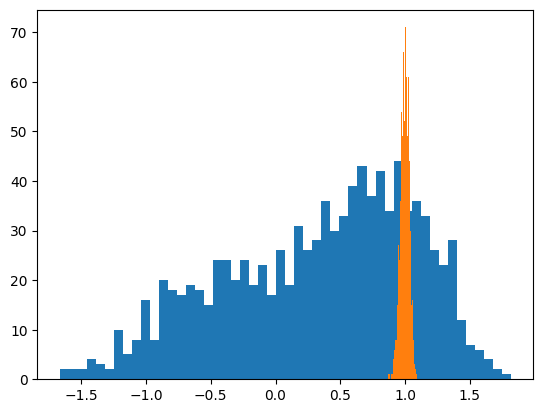

In [31]:
import matplotlib.pyplot as plt

_ = plt.hist(samples["z1"], bins=50)
_ = plt.hist(samples["z2"], bins=50)